## Визуализация и анализ данных (Visuals)

Импортируем очищенный датасет со статистикой по спортивным товарам в pandas DataFrame и выведем строки для проверки.

In [ ]:
import pandas as pd, matplotlib.pyplot as plt, seaborn as sns
df = pd.read_csv('data/Cleaned_Workout_Products.csv')
df

,id,name,brand,category,rating,feedbacks,supplierRating,base_price,discount_price
0,809284740,Турник настенный 3в1 спортивный для дома,Sportlex,турник,4,5,4.7,1567.0,995.0
1,809248305,Турник настенный 3в1 спортивный для дома,Sportlex,турник,5,1,4.7,2293.0,1290.0
2,567252697,Турник настенный 3 в 1,ЭРГОЛАЙН,турник,5,1809,4.8,8800.0,3474.0
3,617571040,Турник настенный 2 хвата,TURNIK.COM,турник,5,639,4.9,12294.0,1448.0
4,172172838,Турник распорный раздвижной в дверной проем,Velton,турник,5,5376,4.8,1267.0,448.0
...,...,...,...,...,...,...,...,...,...
8295,533630185,Гимнастические кольца деревянные 18 см,NaN,гимнастические кольца,5,41,4.9,2100.0,981.0
8296,28698075,Кольца к Уличному спортивному комплексу,Sportlim,гимнастические кольца,5,42,4.8,1311.0,735.0
8297,806277280,"Гимнастические кольца, диаметр хвата 11 мм",NaN,гимнастические кольца,0,0,4.4,3523.0,690.0
8298,175982156,Кольца гимнастические 28 мм (без строп),Мир спорта 365,гимнастические кольца,5,19,4.9,4000.0,1495.0


Для более глубокого визуального анализа добавим новые расчетные метрики: `discount` и `revenue_estimated`.

* **`discount`** - размер скидки на товар в процентах. Рассчитывается на основе `base_price` (первоначальной цены, указанной в карточке товара) и `discount_price` (фактической цены продажи).
* **`revenue_estimated`** - примерная выручка продавца с продаж конкретного товара. Значение является ориентировочным, поскольку при расчете мы приравниваем количество проданных единиц к количеству отзывов (`feedbacks`). В реальности объем продаж, как правило, существенно превышает число оставленных покупателями откликов.

In [2]:
df['discount'] = round((df['base_price'] - df['discount_price'])*100/df['base_price'], 2)
df['revenue_estimated'] = df['discount_price'] * df['feedbacks']
df

,id,name,brand,category,rating,feedbacks,supplierRating,base_price,discount_price,discount,revenue_estimated
0,809284740,Турник настенный 3в1 спортивный для дома,Sportlex,турник,4,5,4.7,1567.0,995.0,36.50,4975.0
1,809248305,Турник настенный 3в1 спортивный для дома,Sportlex,турник,5,1,4.7,2293.0,1290.0,43.74,1290.0
2,567252697,Турник настенный 3 в 1,ЭРГОЛАЙН,турник,5,1809,4.8,8800.0,3474.0,60.52,6284466.0
3,617571040,Турник настенный 2 хвата,TURNIK.COM,турник,5,639,4.9,12294.0,1448.0,88.22,925272.0
4,172172838,Турник распорный раздвижной в дверной проем,Velton,турник,5,5376,4.8,1267.0,448.0,64.64,2408448.0
...,...,...,...,...,...,...,...,...,...,...,...
8295,533630185,Гимнастические кольца деревянные 18 см,NaN,гимнастические кольца,5,41,4.9,2100.0,981.0,53.29,40221.0
8296,28698075,Кольца к Уличному спортивному комплексу,Sportlim,гимнастические кольца,5,42,4.8,1311.0,735.0,43.94,30870.0
8297,806277280,"Гимнастические кольца, диаметр хвата 11 мм",NaN,гимнастические кольца,0,0,4.4,3523.0,690.0,80.41,0.0
8298,175982156,Кольца гимнастические 28 мм (без строп),Мир спорта 365,гимнастические кольца,5,19,4.9,4000.0,1495.0,62.62,28405.0


Построим **boxplot (ящик с усами)** для каждой из шести категорий товаров. По оси X отобразим фактическую цену продажи (`discount_price`). Чтобы графики для всех категорий оставались наглядными и легко читаемыми, ограничим ось X значением в 12 000 рублей.

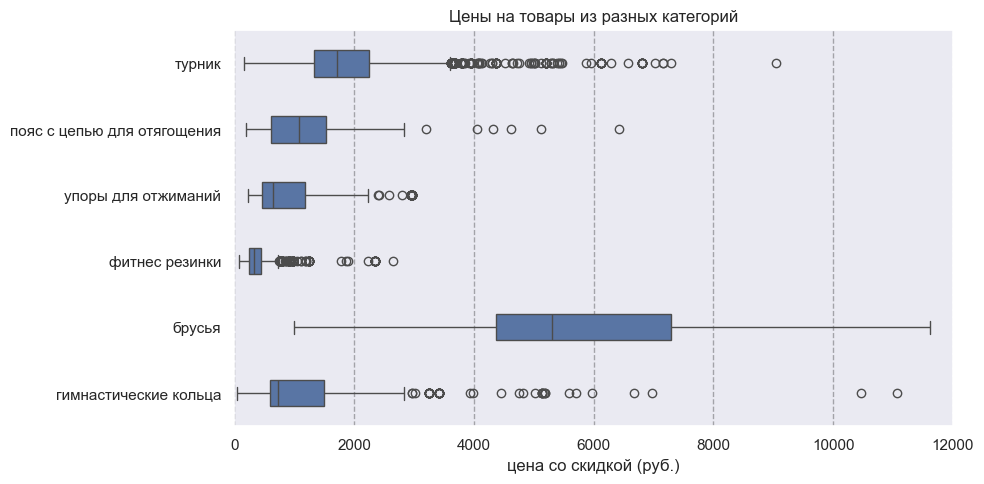

In [24]:
plt.figure(figsize=(10,5))
sns.set_theme(style="darkgrid", palette="deep")
sns.boxplot(data=df, x = 'discount_price', y = 'category', width = .4)
plt.grid(axis="x", linestyle="--", alpha=0.3, color="black")
plt.xlim(0, 12000)
plt.xlabel("цена со скидкой (руб.)")
plt.ylabel("")
plt.title("Цены на товары из разных категорий")
plt.tight_layout()

На основании графика можно сделать следующие выводы:

- **Фитнес-резинки**, ожидаемо, являются самой дешёвой категорией товаров для воркаута. Цена в основном держится на уровне 300-500 руб. или меньше. Присутствуют выбросы от 1000 руб. до 2500 руб. Возможно, они представляют собой большие наборы резинок разного калибра.

- В свою очередь **брусья** представляют собой самую дорогую категорию спорттоваров, с медианой по цене около 5000-6000 руб. Максимум уходит дальше отметки в 10000 руб. Премиальные модели, вероятно, стоят дороже.

- **Турники** предоставляют большой разброс по ценам. Цена в среднем 2000 руб., но присутствуют и товары с ценой от 4000 руб. до 7000+ руб. Вероятно, это дорогие модели, например комплекс 3 в 1 (турник + брусья + пресс), напольные турники или турники, поддерживающие разнообразные виды хвата.

- У товаров категории **гимнастические кольца** медианная цена достаточно низкая, в целом, недалеко от тех же фитнес-резинок. Однако в сравнении с ними можно увидеть выбросы на отметках 3000 руб., 6000 руб. и даже 10000+ руб! Скорее всего, это связано с тем, что на маркетплейсе есть как дешёвые детские модели, так и специализированные гимнастические кольца для атлетов из качественных пород дерева.

- **Упоры для отжиманий** находятся в целом в том же положении, что и **гимнастические кольца**, однако количество выбросов и разброс по ценам значительно меньше, если у колец предел 10000+ руб., то у упоров около 3000 руб.

- Товары типа **пояс с цепью для отягощения** входят в тройку самых дорогих категорий, после **турников** и **брусьев**, цена в среднем 1000-1500 руб. Присутствуют отдельные товары с ценами от 3000 руб. до 6000 руб.

Проанализируем бренды спортивных товаров. Построим два графика: топ-10 брендов по количеству карточек товаров и топ-10 брендов по размеру продаж. Посмотрим, какие бренды присутствуют в обоих графиках, а какие представлены только на одном из графиков.

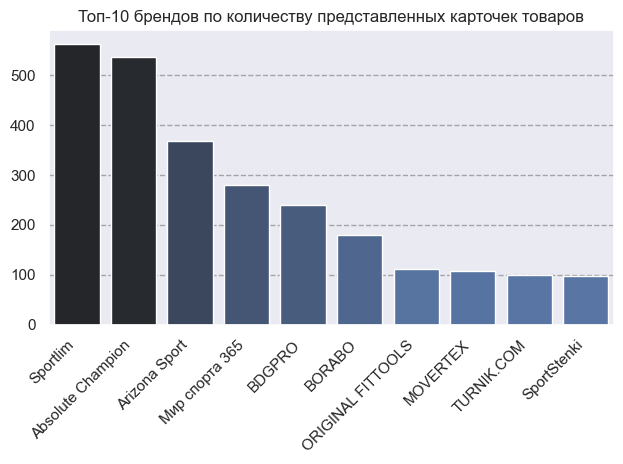

In [39]:
brand_data = df['brand'].value_counts().head(10).reset_index()
sns.barplot(data=brand_data, x='brand', y='count', hue = 'count', palette = 'dark:b_r', legend=False)
plt.xticks(rotation=45, ha='right')
plt.grid(axis="y", linestyle="--", alpha=0.3, color="black")
plt.ylabel("")
plt.xlabel("")
plt.title("Топ-10 брендов по количеству представленных карточек товаров")
plt.tight_layout()

In [5]:
brand_data_revenue = (
    df.groupby('brand')['revenue_estimated']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)
brand_data_revenue['revenue_mln'] = brand_data_revenue['revenue_estimated'] / 1_000_000

brand_data_revenue

,brand,revenue_estimated,revenue_mln
0,Absolute Champion,1.660756e+09,1660.756039
1,Down Up,1.111344e+09,1111.343870
2,Уралспорт МК,5.949496e+08,594.949554
3,HOMEGYMS,5.304701e+08,530.470116
4,Arizona Sport,4.808398e+08,480.839787
5,DFC,3.993149e+08,399.314855
6,P.O.SPORT,3.754809e+08,375.480879
7,Aktiv,2.749485e+08,274.948497
8,BDGPRO,2.535085e+08,253.508471
9,LGGIN,2.372348e+08,237.234837


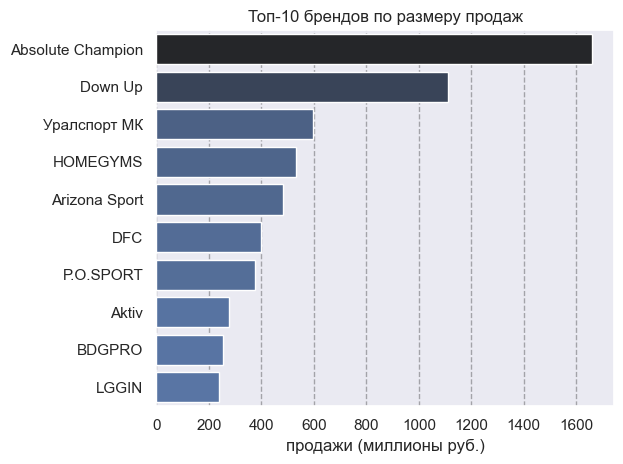

In [ ]:
sns.barplot(data=brand_data_revenue,  x='revenue_mln', y='brand', legend=False, hue = 'revenue_mln', palette = 'dark:b_r')
plt.grid(axis="x", linestyle="--", alpha=0.3, color="black")
plt.ylabel("")
plt.xlabel("продажи (миллионы руб.)")
plt.title("Топ-10 брендов по размеру продаж")
plt.tight_layout()

На основании полученных графиков можно сделать следующие выводы:

- **Absolute Champion** является "абсолютным чемпионом". Он занимает первое место по размеру продаж и второе по количеству представленных карточек.

- Некоторые бренды, которые представлены в топе по карточкам **не представлены** в топе по продажам (**Sportlim**, **Мир спорта 365** и др.). Количество представленных товаров не гарантирует высокие продажи.

- Бренды Arizona Sport и BDGPRO демонстрируют сбалансированную стратегию: они одновременно входят в топ-10 по широте ассортимента и в топ-10 по объёму продаж. Это говорит о здоровом соотношении между количеством карточек и их рыночной эффективностью, в отличие от брендов с большим числом товаров, но низкими продажами.

Проведём анализ скидок на спорттовары: действительно ли продавцы ставят огромные скидочные цены для привлечения покупателей?

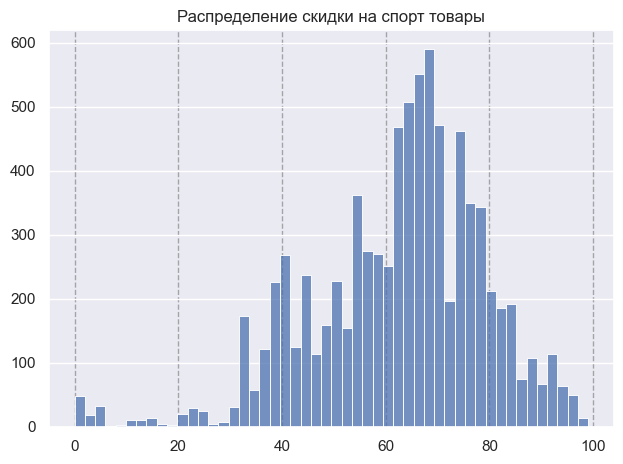

In [7]:
sns.histplot(data = df, x = 'discount')

plt.grid(axis="x", linestyle="--", alpha=0.3, color="black")

plt.xlabel("")
plt.ylabel("")
plt.title("Распределение скидки на спорт товары")

plt.tight_layout()

Полученная гистограмма позволяет сказать следующее:

- Абсолютное большинство скидок попадает в сектор 60%-80%. Это свидетельствует не столько о щедрости продавцов, сколько о повсеместном завышении базовой цены для создания иллюзии большой выгоды для покупателя. Подобный маркетинговый приём стал на площадке фактически стандартом.

- Присутствуют всплески около круглых значений, что логично. Скидка в размере 50% выглядит понятнее и привлекательнее, нежели 49% или 53%.

- Крайне небольшие всплески присутствуют около значений 0% и 100%. Вероятно, в случае 0% - это свежие или уникальные спорттовары, либо особенности работы с WB - например, тот факт, что лучше поставить хоть какую-то скидку, чем 0%. Значения около 100% - скорее всего, ликвидация остатков, возможно, участие в акциях WB.

Построим **scatterplot (диаграмму рассеяния)**: для анализа зависимости количества отзывов от цены товара

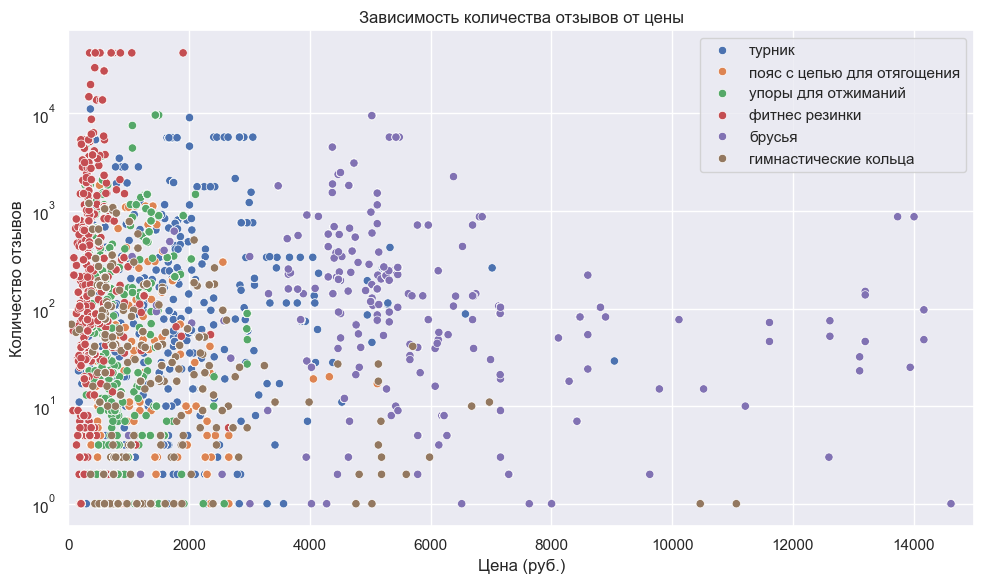

In [28]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df[df['feedbacks'] > 0], x='discount_price', y='feedbacks', hue='category', alpha=1)
plt.xlim(0, 15000)
plt.yscale('log')
plt.title("Зависимость количества отзывов от цены")
plt.xlabel("Цена (руб.)")
plt.ylabel("Количество отзывов")
plt.legend(title = "")
plt.tight_layout()

На основе диаграммы рассеяния можно увидеть, что:

- Пик отзывов приходится на дешёвые товары, которые преимущественно представлены категорией **фитнес-резинки** (сконцентрированы в крайней левой области графика).

- Чуть правее и ниже резинок расположились такие категории, как **гимнастические кольца**, **упоры для отжиманий** и **пояса с цепью для отягощения**. В основном все эти категории, включая резинки, заняли отметку в цене до 2000 руб. и имеют наибольшее суммарное количество отзывов.

- По сравнению с остальными категориями, **турники** распределились достаточно равномерно по цене на отметках 1000-5000 руб. Тем не менее многие товары из этой категории всё равно сбились на отметке до 2000 руб. - они же имеют наибольшее количество отзывов.

- Товары категории **брусья** только начинают появляться на отметках 3000-4000 руб. Их пик по количеству товаров и по отзывам приходится на диапазон 4000-6000 руб. Далее они уходят на отметки 7000-14000+ руб. Количество отзывов падает на высоких ценниках, однако некоторые товары даже на отметках выше 10000 руб. поддерживают количество отзывов от 100 до 1000.

- Можно отдельно выделить выбросы категории **гимнастические кольца**, которые стоят от 5000+ руб. По сравнению с дешёвыми детскими моделями они имеют значительно меньше отзывов. Самые дорогие модели в районе 10000 руб. вообще почти без отзывов.